In [1]:
import pandas as pd
import matplotlib.pyplot as plt # visualizing data
import seaborn as sns

In [2]:
df = pd.read_csv("MusicData.csv")

In [3]:
df.head()

,index,Format,Metric,Year,Number of Records,Value (Actual)
0,0,CD,Units,1973,1,NaN
1,1,CD,Units,1974,1,NaN
2,2,CD,Units,1975,1,NaN
3,3,CD,Units,1976,1,NaN
4,4,CD,Units,1977,1,NaN


In [4]:
df.shape

(3008, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3008 entries, 0 to 3007
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              3008 non-null   int64  
 1   Format             3008 non-null   object 
 2   Metric             3008 non-null   object 
 3   Year               3008 non-null   int64  
 4   Number of Records  3008 non-null   int64  
 5   Value (Actual)     1351 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 141.1+ KB


In [6]:
df.describe()

,index,Year,Number of Records,Value (Actual)
count,3008.00000,3008.000000,3008.0,1351.000000
mean,1503.50000,1996.000000,1.0,781.291237
std,868.47913,13.566915,0.0,2246.837672
min,0.00000,1973.000000,1.0,-7.650944
25%,751.75000,1984.000000,1.0,3.700228
50%,1503.50000,1996.000000,1.0,63.900000
75%,2255.25000,2008.000000,1.0,448.900000
max,3007.00000,2019.000000,1.0,19667.327786


In [ ]:
df["Format"].nunique()

24

In [10]:
df.isnull().sum()

index                   0
Format                  0
Metric                  0
Year                    0
Number of Records       0
Value (Actual)       1657
dtype: int64

In [9]:
df.dropna()

,index,Format,Metric,Year,Number of Records,Value (Actual)
10,10,CD,Units,1983,1,0.800000
11,11,CD,Units,1984,1,5.800000
12,12,CD,Units,1985,1,22.600000
13,13,CD,Units,1986,1,53.000000
14,14,CD,Units,1987,1,102.100000
...,...,...,...,...,...,...
3003,3003,Vinyl Single,Value (Adjusted),2015,1,6.205390
3004,3004,Vinyl Single,Value (Adjusted),2016,1,5.198931
3005,3005,Vinyl Single,Value (Adjusted),2017,1,6.339678
3006,3006,Vinyl Single,Value (Adjusted),2018,1,5.386197


In [8]:
df.duplicated().sum()

0

In [13]:
df.columns

Index(['index', 'Format', 'Metric', 'Year', 'Number of Records',
       'Value (Actual)'],
      dtype='object')

In [17]:
pd.set_option("display.float_format", "{:.2f}".format)

In [ ]:
# Calculate the mean of "Value (Actual)" for each year and display the five years with the lowest mean values

yearly_mean = df.groupby("Year")["Value (Actual)"].mean().sort_values(ascending=False).tail(5)
yearly_mean

Year
2010   353.74
2011   341.49
2014   334.74
2015   331.01
2016   320.52
Name: Value (Actual), dtype: float64

C:\Users\PRATIK MISHRA\AppData\Local\Temp\ipykernel_16348\3893042496.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_mean.index, y=yearly_mean.values, width=0.5, palette="summer")


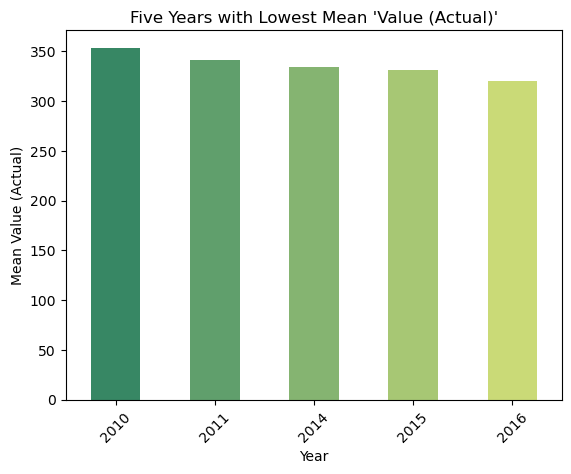

In [ ]:
# Visualize the results using a bar plot

sns.barplot(x=yearly_mean.index, y=yearly_mean.values, width=0.5, palette="summer")
plt.title("Five Years with Lowest Mean 'Value (Actual)'")
plt.xlabel("Year")
plt.ylabel("Mean Value (Actual)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Display the top 5 most common formats

df["Format"].value_counts().head(5)

Format
CD                       141
DVD Audio                141
Ringtones & Ringbacks    141
Download Music Video     141
Kiosk                    141
Name: count, dtype: int64

In [26]:
# Sort the DataFrame by "Year" in ascending order and display the first five rows

df_sorted = df.sort_values("Year")
df_sorted.head(5)

,index,Format,Metric,Year,Number of Records,Value (Actual)
0,0,CD,Units,1973,1,NaN
1833,1833,Synchronization,Value,1973,1,NaN
2773,2773,Ringtones & Ringbacks,Value (Adjusted),1973,1,NaN
1786,1786,SoundExchange Distributions,Value,1973,1,NaN
611,611,Kiosk,Units,1973,1,NaN


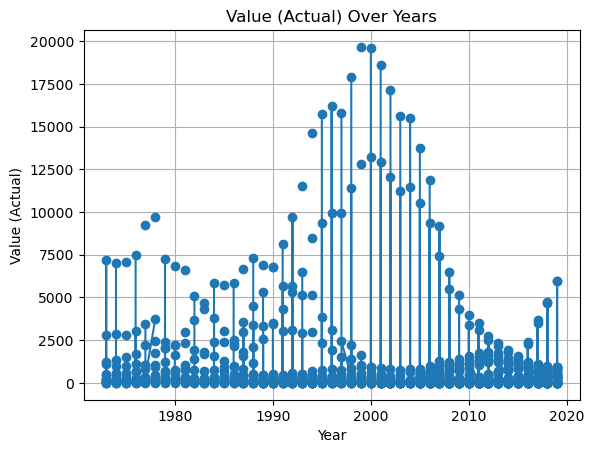

In [ ]:
# Visualize "Value (Actual)" over the years using a line plot

plt.plot(df_sorted["Year"], df_sorted["Value (Actual)"], marker='o')
plt.title("Value (Actual) Over Years")
plt.xlabel("Year")
plt.ylabel("Value (Actual)")
plt.grid(True)
plt.show()

In [ ]:
# Sum "Value (Actual)" for each format and sort in descending order

df.groupby("Format")["Value (Actual)"].max().sort_values(ascending=False)

Format
CD                                   19667.33
LP/EP                                 9698.11
Cassette                              7315.51
Paid Subscription                     5934.40
8 - Track                             3717.22
Download Single                       1831.26
Download Album                        1352.20
Ringtones & Ringbacks                 1302.09
Vinyl Single                          1245.18
SoundExchange Distributions            970.06
On-Demand Streaming (Ad-Supported)     908.15
Limited Tier Paid Subscription         829.50
Music Video (Physical)                 821.78
Cassette Single                        544.48
CD Single                              434.38
Synchronization                        290.69
Other Ad-Supported Streaming           273.04
Other Tapes                             89.83
Paid Subscriptions                      60.38
Download Music Video                    49.04
SACD                                    36.54
Other Digital              

In [ ]:
# Sum "Value (Actual)" for each format and sort in descending order

df.groupby("Format")["Value (Actual)"].sum().sort_values(ascending=False)

Format
CD                                   525411.02
Cassette                             157208.10
LP/EP                                127648.81
Download Single                       45894.16
Paid Subscription                     42514.17
8 - Track                             30159.46
Download Album                        25107.07
Vinyl Single                          22055.18
Music Video (Physical)                18437.06
SoundExchange Distributions           14331.81
Ringtones & Ringbacks                 13499.36
On-Demand Streaming (Ad-Supported)     8136.51
Cassette Single                        7227.23
Synchronization                        4934.39
Limited Tier Paid Subscription         4919.18
CD Single                              4353.30
Other Ad-Supported Streaming           1712.16
Download Music Video                    724.89
Paid Subscriptions                      351.44
Other Tapes                             280.68
SACD                                    183.74
DVD Au

In [ ]:
# Calculate the mean "Value (Actual)" for each combination of "Format" and "Year", sorted in descending order

df.groupby(["Format", "Year"])["Value (Actual)"].mean().sort_values(ascending=False)

Format           Year
CD               2000   11258.64
                 1999   11140.84
                 2001   10808.99
                 1998   10056.13
                 2002    9987.78
                          ...   
Synchronization  2004        NaN
                 2005        NaN
                 2006        NaN
                 2007        NaN
                 2008        NaN
Name: Value (Actual), Length: 1128, dtype: float64

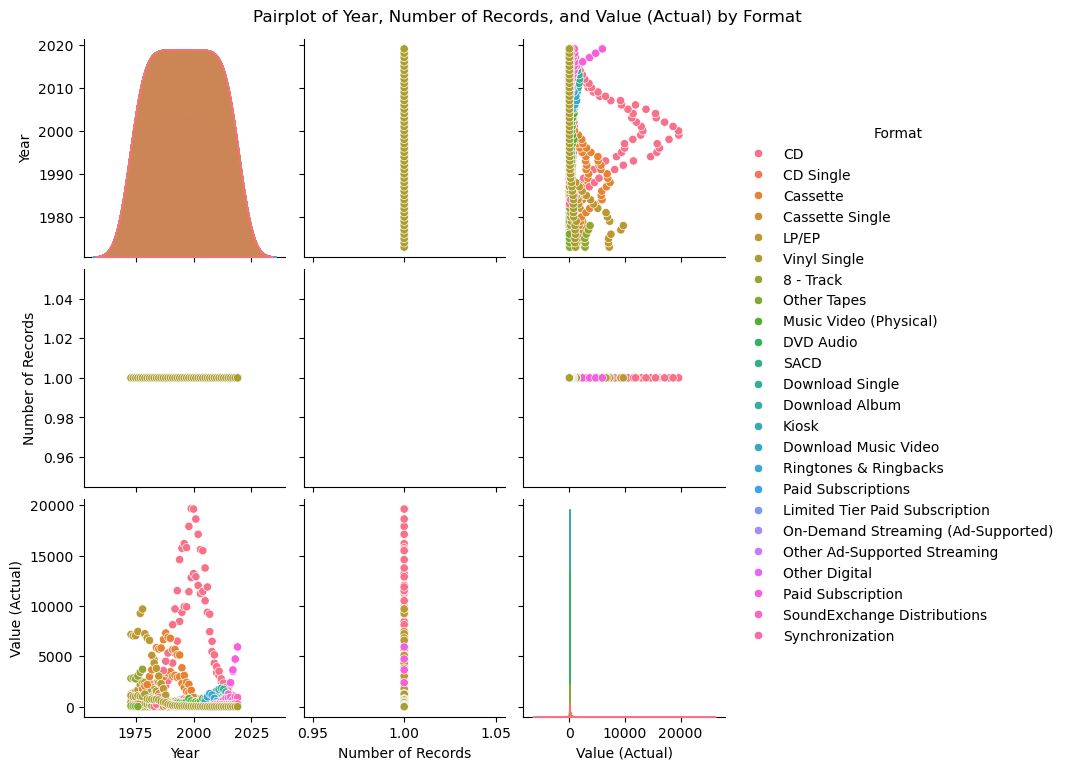

In [37]:
# Create a pairplot to visualize relationships between "Year", "Number of Records", and "Value (Actual)" colored by "Format"

sns.pairplot(df, vars=["Year", "Number of Records", "Value (Actual)"], hue="Format")
plt.suptitle("Pairplot of Year, Number of Records, and Value (Actual) by Format", y=1.02)
plt.show()

In [36]:
df.columns

Index(['index', 'Format', 'Metric', 'Year', 'Number of Records',
       'Value (Actual)'],
      dtype='object')

In [ ]:
# Create a stacked bar chart showing the sum of "Value (Actual)" for each "Metric" across different "Year"s

year_mertric_sum = df.groupby(["Year","Metric"])["Value (Actual)"].sum().unstack().head(10)

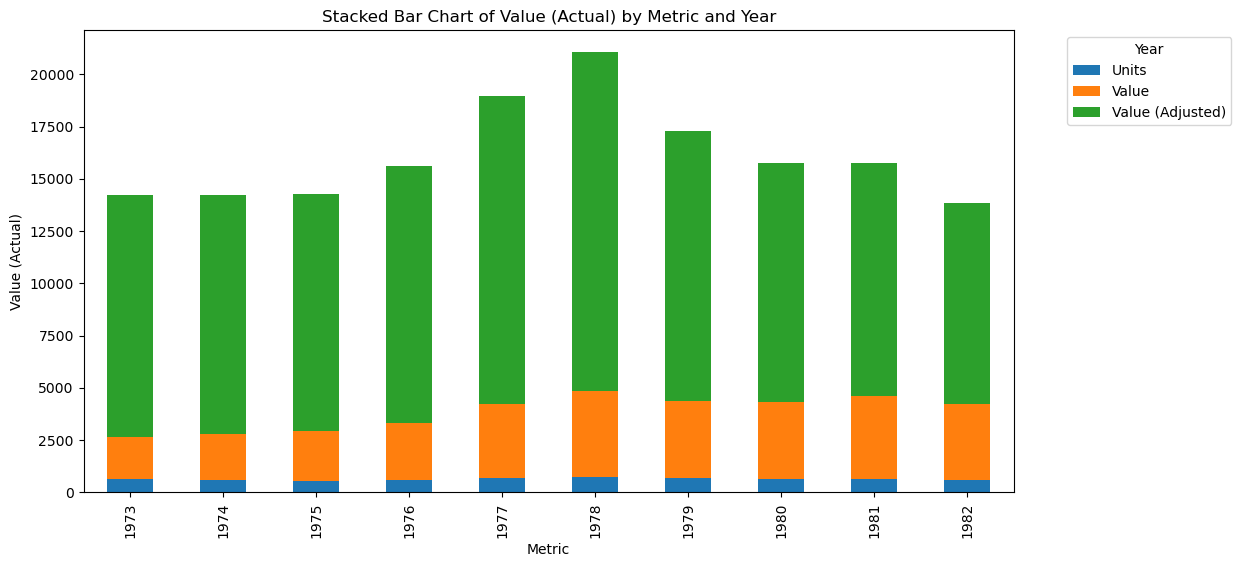

In [ ]:
# Plot the stacked bar chart

year_mertric_sum.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Stacked Bar Chart of Value (Actual) by Metric and Year")
plt.xlabel("Metric")
plt.ylabel("Value (Actual)")
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()